<a href="https://colab.research.google.com/github/MarioV3232/CasoPracticoProduccionIndustrial/blob/main/Notebooks/Caso_Practico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ACTIVIDAD 1**

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/MarioV3232/CasoPracticoProduccionIndustrial/refs/heads/main/Data/Prestige_modificado.csv"

df = pd.read_csv(url, sep=';')

df.head()

,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


In [2]:
print(df.shape)

(102, 7)


In [3]:
print(df.head())

            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB


In [5]:
print("Valores nulos:")
print(df.isnull().sum())

print("\nRegistros duplicados:", df.duplicated().sum())

Valores nulos:
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64

Registros duplicados: 0


In [6]:
df.describe()

,education,income,women,prestige,census,type_num
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,10.738039,6797.901961,28.979020,46.833333,5401.774510,1.843137
std,2.728444,4245.922227,31.724931,17.204486,2644.993215,0.817447
min,6.380000,611.000000,0.000000,14.800000,1113.000000,0.000000
25%,8.445000,4106.000000,3.592500,35.225000,3120.500000,1.000000
50%,10.540000,5930.500000,13.600000,43.600000,5135.000000,2.000000
75%,12.647500,8187.250000,52.202500,59.275000,8312.500000,2.000000
max,15.970000,25879.000000,97.510000,87.200000,9517.000000,3.000000


**ACTIVIDAD 2**

In [7]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))

           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000


In [8]:
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))

prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


**ACTIVIDAD 3**

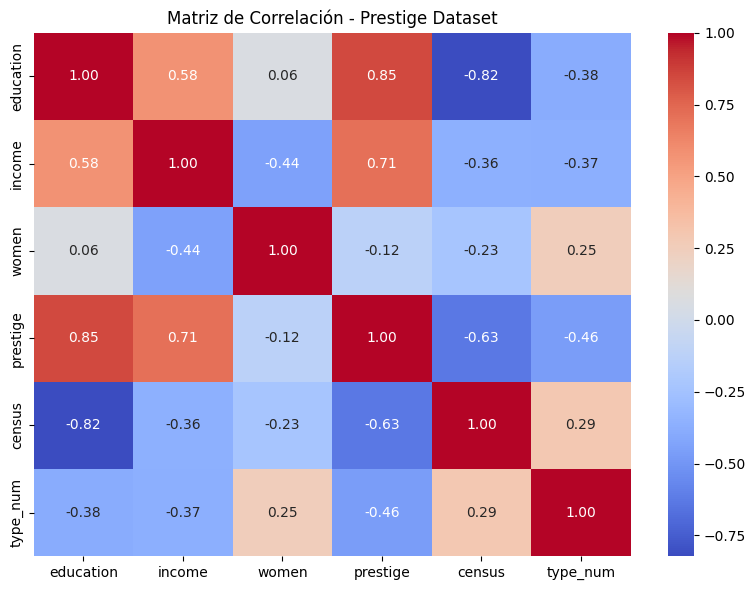

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(matriz_correlacion, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación - Prestige Dataset')
plt.tight_layout()
plt.show()

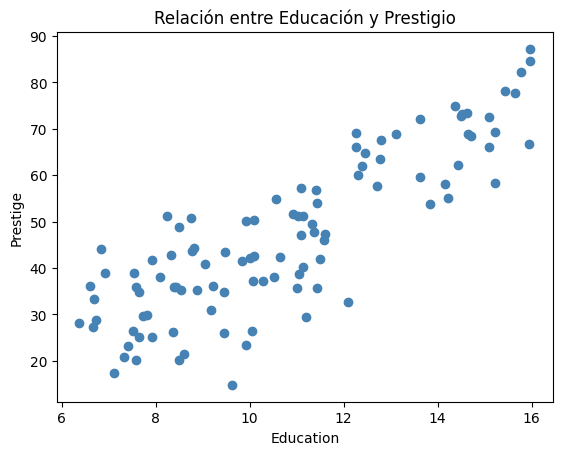

In [10]:
plt.figure()
plt.scatter(df['education'], df['prestige'], color='steelblue')
plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Relación entre Educación y Prestigio')
plt.show()

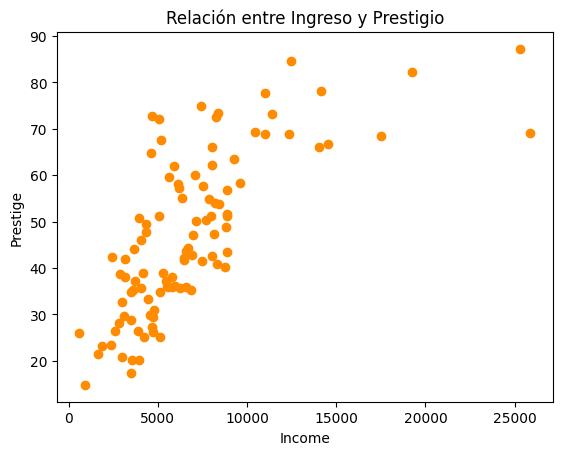

In [11]:
plt.figure()
plt.scatter(df['income'], df['prestige'], color='darkorange')
plt.xlabel('Income')
plt.ylabel('Prestige')
plt.title('Relación entre Ingreso y Prestigio')
plt.show()

<Figure size 800x500 with 0 Axes>

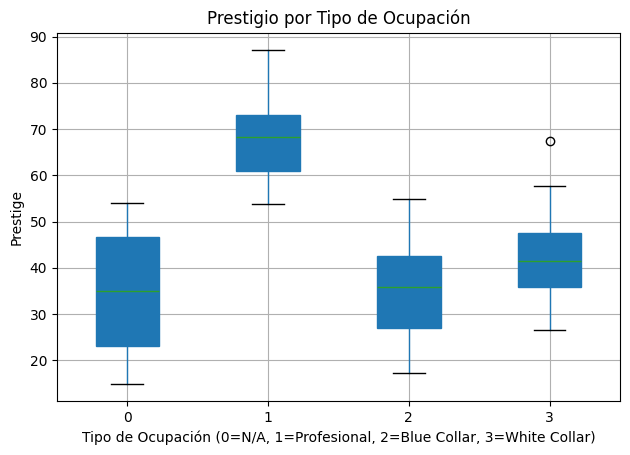

In [12]:
plt.figure(figsize=(8,5))
df.boxplot(column='prestige', by='type_num', patch_artist=True)
plt.title('Prestigio por Tipo de Ocupación')
plt.suptitle('')
plt.xlabel('Tipo de Ocupación (0=N/A, 1=Profesional, 2=Blue Collar, 3=White Collar)')
plt.ylabel('Prestige')
plt.tight_layout()
plt.show()

**ACTIVIDAD 4**

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [14]:
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

In [15]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

In [16]:
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

In [17]:
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

In [18]:
print("=== CENTROIDES K=4 ===")
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))

=== CENTROIDES K=4 ===
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00


In [19]:
print("\n=== CENTROIDES K=5 ===")
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))


=== CENTROIDES K=5 ===
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00


**ACTIVIDAD 5**

1.	¿Qué variables parecen tener mayor relación con el prestigio de una ocupación?

Las variables con mayor relación con el prestigio son education (0.850) e income (0.715). Esto indica que las ocupaciones mejor valoradas socialmente tienden a requerir mayor nivel educativo y generan mayores ingresos. La variable women mostró una relación muy débil (-0.118), por lo que el porcentaje de mujeres en una ocupación no parece ser un factor determinante del prestigio en este dataset

2.	¿Cómo podría una empresa de software usar este tipo de análisis para valorar roles técnicos, gerenciales o de soporte?


InnovaSoft Analytics podría aplicar este tipo de análisis para diseñar estructuras salariales y de reconocimiento más justas. Si la educación y el ingreso son los factores más asociados al prestigio, la empresa debería invertir en formación técnica continua para sus colaboradores, ya que esto no solo mejora su capacidad productiva sino también su valoración dentro de la organización. Roles como arquitectos de software, líderes técnicos y gerentes de proyectos, que requieren mayor formación, deberían recibir una valoración acorde a su nivel educativo y responsabilidad

3.	¿Qué grupos de ocupaciones se identificaron y cómo podrían interpretarse?

Con el modelo de 5 clústeres se identificaron los siguientes perfiles:

Cluster 4: Elite profesional — alta educación, máximo ingreso y prestigio. Equivalente a roles senior o directivos en software.

Cluster 2: Profesionales educados — buen nivel educativo y prestigio alto. Corresponde a perfiles técnicos especializados.

Cluster 1: Blue collar masculino — educación e ingresos medios, prestigio moderado. Similar a roles operativos o de soporte técnico.

Cluster 0: Ocupaciones femeninas — ingresos bajos, prestigio medio. Sugiere posibles brechas de género en valoración.

Cluster 3: Bajo perfil — menor educación, ingresos y prestigio más bajos. Roles de entrada o sin especialización.

4.	¿Existen resultados que parezcan anómalos o difíciles de explicar?

El resultado más llamativo es que el aislamiento de la variable women no mostró correlación significativa con el prestigio, lo cual podría interpretarse de dos formas: o bien el género no determina el prestigio directamente, o bien el dataset no captura suficiente variabilidad para detectar esa relación. También llama la atención que el Cluster 0 (ocupaciones con alta participación femenina) tenga ingresos bajos a pesar de un prestigio moderado, lo que podría reflejar una brecha de género en compensación económica.

5.	¿Qué información adicional haría falta para tomar mejores decisiones?


Para mejorar el análisis en un contexto real de producción de software, sería útil contar con:

.Años de experiencia por ocupación

.Nivel de especialización técnica o certificaciones

.Datos de desempeño o productividad

.Información sobre rotación de personal

.Variables específicas del sector tecnológico, ya que el dataset Prestige proviene de un contexto ocupacional general y no del sector software directamente